# Application 4 — Light-sheet microscopy: nuclei in a cleared mouse brain (CellSeg3D)

**Modality:** mesoSPIM light-sheet fluorescence microscopy of a CLARITY-cleared mouse brain (TPH2-tdTomato);
5.26 × 5.26 µm pixels, 5 µm z-step. **Objects:** cell nuclei.

**Dataset:** the annotated light-sheet volumes of CellSeg3D — Achard, C., Kousi, T., Frey, M., Vidal, M., Paychère, Y., Hofmann, C.,
Iqbal, A., Hausmann, S. B., Pagès, S. and Mathis, M. W. *CellSeg3D: self-supervised 3D cell segmentation for fluorescence microscopy.*
eLife 13:RP99848, [doi:10.7554/eLife.99848](https://doi.org/10.7554/eLife.99848).
Data: Mathis Laboratory of Adaptive Intelligence, Zenodo, [doi:10.5281/zenodo.11095111](https://doi.org/10.5281/zenodo.11095111),
licence CC-BY-4.0. The volumes are crops of the whole-brain mesoSPIM data of Voigt et al. (2019), *Nat. Methods* 16:1105–1108
(IDR0066).

**What this notebook does:** downloads the archive (30.6 MB, checked against its MD5), takes volume `c3`
(299 × 105 × 147 voxels, 631 labelled nuclei), derives one box per nucleus, loads the boxes into the synchronized four-viewer layout,
replays a mouse drag on one box, and exports native, COCO and YOLO files.

In [1]:
SHOW = False  # True: open the four napari windows (needs a desktop session)

if SHOW:
    get_ipython().run_line_magic("gui", "qt")

import json
from pathlib import Path

import numpy as np
from IPython.display import Image, display

import tutorial_utils as tu

CASE = "04_light_sheet_cellseg3d_mouse_brain"
DATA = tu.data_dir('cellseg3d')  # $TURBOBOX_DATA/<subdir>, else ~/.cache/napari-turbobox/<subdir>
OUT = DATA / "export"
print("data directory:", tu.show_path(DATA))

data directory: ~/.cache/napari-turbobox/cellseg3d


## 1. Download


The archive holds five annotated volumes (`c1`–`c5`) plus a larger visualisation volume; we use `c3`, the one with the most nuclei.

In [2]:
ZIP_URL = "https://zenodo.org/api/records/11095111/files/DATASET_WITH_GT.zip/content"
archive = tu.fetch(ZIP_URL, DATA / "DATASET_WITH_GT.zip", size=30_597_955, md5="fbcaf6d4e65b99eac7caa082f6798542")
img_path = tu.extract_member(archive, "DATASET_WITH_GT/c3image.tif", DATA / "c3image.tif")
lab_path = tu.extract_member(archive, "DATASET_WITH_GT/labels/c3labels_new_label.tif", DATA / "c3labels_new_label.tif")

## 2. Load the volume


The TIFF files carry no voxel size; the CellSeg3D paper gives 5.26 µm pixels and a 5 µm z-step.
Boxes stay in voxel indices; `SCALE` only makes napari display the volume in µm.
The label ids have gaps; `find_objects` handles that.

In [3]:
import tifffile

image = tifffile.imread(img_path)
labels = tifffile.imread(lab_path)
SCALE = (5.0, 5.26, 5.26)  # µm per voxel (z, y, x), CellSeg3D paper
CONTRAST = None
print("image", image.shape, image.dtype, "| labels", labels.shape, labels.dtype, "|", len(np.unique(labels)) - 1, "nuclei")

image (299, 105, 147) uint16 | labels (299, 105, 147) int64 | 631 nuclei


## 3. One box per object


Each labelled nucleus becomes the box from its first to its last voxel index on every axis (`scipy.ndimage.find_objects`).

In [4]:
boxes, ids = tu.labels_to_boxes(labels)
print(len(boxes), "boxes from", len(ids), "labels")

631 boxes from 631 labels


In [5]:
check = tu.check_boxes(boxes, image.shape)
print(f"{check['valid']} of {check['boxes']} boxes satisfy 0 <= min, max <= shape - 1, max - min >= 1")
extent = boxes[:, 1] - boxes[:, 0]
print("median box extent (z, y, x) in voxels:", np.median(extent, axis=0).tolist())

631 of 631 boxes satisfy 0 <= min, max <= shape - 1, max - min >= 1
median box extent (z, y, x) in voxels: [21.0, 4.0, 4.0]


## 4. The synchronized four-viewer layout

XY is the editable view; XZ, YZ and 3D are read-only and display the same box store.
`add_boxes` validates every box against the image shape, so a `ValueError` here would mean an invalid box.
The screenshot shows the four canvases (XY, XZ, YZ, 3D), each 2D view on a slice through one median-sized box.

631 boxes in the shared store; shapes drawn per view: [74, 32, 21, 631]


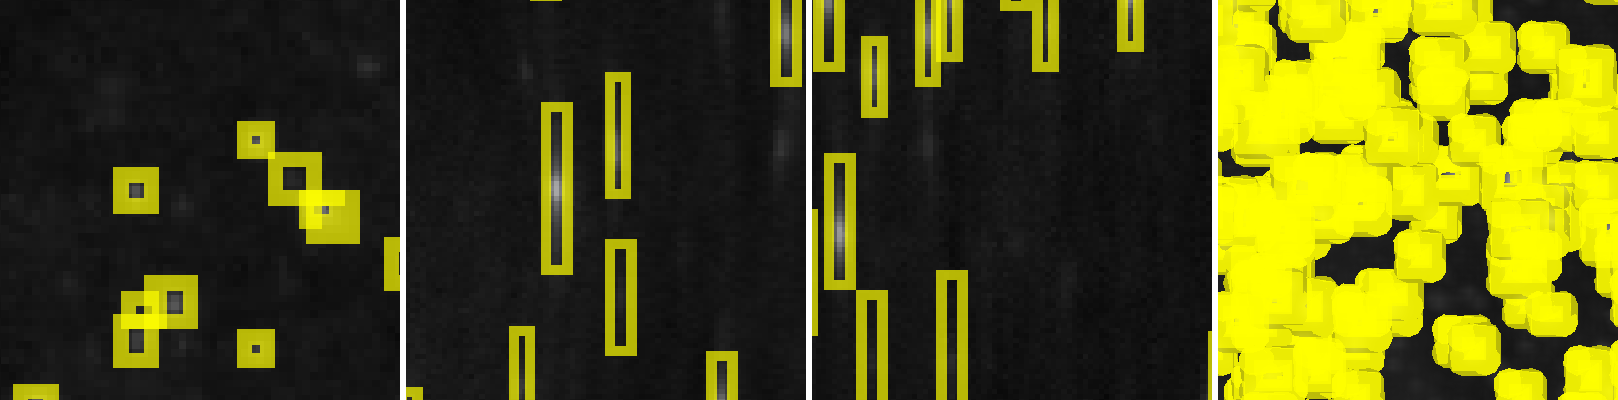

In [6]:
k = tu.pick_box(boxes)
viewers, layers = tu.four_viewer_layout(
    image, boxes, show=SHOW, scale=SCALE, contrast_limits=CONTRAST, focus_box=k
)
print(len(layers[0].bounding_boxes), "boxes in the shared store;",
      "shapes drawn per view:", [lyr.nshapes for lyr in layers])
shot = tu.RESULTS / f"{CASE}_views.png"
tu.screenshot(viewers, shot)
display(Image(filename=str(shot)))

## 5. Replaying a mouse drag

The drag below goes through napari's own mouse-event dispatch, the same path as a real mouse:
it grabs box `k` in the XY view at its centre and moves it by a quarter of its size in y and x.
We check that the box stays a valid box, that the read-only XZ and YZ views and the 3D view show it at the new position,
and that one undo step restores it.

In [7]:
drag = tu.replay_drag(viewers, layers, k)
print("shift (z, y, x):", drag["shift_zyx"], "intended:", drag["intended_shift_zyx"])
print("still a valid box:", drag["valid"])
print("read-only views show the moved box:", drag["views_show_moved_box"])
layers[0].undo()
print("undo restores all boxes:", np.array_equal(layers[0].bounding_boxes, boxes.astype(np.float32)))

shift (z, y, x): [0.0, 1.0, 1.0] intended: [0.0, 1.0, 1.0]
still a valid box: True
read-only views show the moved box: {'XZ (read-only)': True, 'YZ (read-only)': True, '3D (read-only)': True}


undo restores all boxes: True


## 6. Export

Native `boxes.npy` (the format of the control panel's import/export), COCO JSON with one 2D box per slice that a 3D box covers,
and one YOLO label file per slice. Slice images are named `slice_NNNN.png`; the exporter writes no image files.

In [8]:
counts = tu.export(layers[0].bounding_boxes, image.shape, OUT, label_ids=ids)
print(json.dumps(counts, indent=1))
print("files in", tu.show_path(OUT), ":", sorted(p.name for p in OUT.iterdir()))

{
 "boxes": 631,
 "coco_images": 299,
 "coco_annotations": 13839,
 "yolo_files": 299
}
files in ~/.cache/napari-turbobox/cellseg3d/export : ['boxes.npy', 'coco_per_slice.json', 'label_ids.npy', 'yolo']


In [9]:
result = dict(
    case=CASE,
    modality="light-sheet fluorescence microscopy (mesoSPIM)",
    objects="cell nuclei (instance labels)",
    dataset="CellSeg3D, Achard et al. (eLife); Zenodo doi:10.5281/zenodo.11095111 (CC-BY-4.0)",
    volume="DATASET_WITH_GT/c3image.tif",
    box_source="ground-truth instance labels",
)
result.update(check=check, export=counts, drag=drag, image_shape=list(image.shape), n_boxes=int(len(boxes)))
print(json.dumps({k: v for k, v in result.items() if k != "drag"}, indent=1))
tu.show_path(tu.save_result(CASE, result))

{
 "case": "04_light_sheet_cellseg3d_mouse_brain",
 "modality": "light-sheet fluorescence microscopy (mesoSPIM)",
 "objects": "cell nuclei (instance labels)",
 "dataset": "CellSeg3D, Achard et al. (eLife); Zenodo doi:10.5281/zenodo.11095111 (CC-BY-4.0)",
 "volume": "DATASET_WITH_GT/c3image.tif",
 "box_source": "ground-truth instance labels",
 "check": {
  "boxes": 631,
  "valid": 631
 },
 "export": {
  "boxes": 631,
  "coco_images": 299,
  "coco_annotations": 13839,
  "yolo_files": 299
 },
 "image_shape": [
  299,
  105,
  147
 ],
 "n_boxes": 631
}


'tutorials/results/04_light_sheet_cellseg3d_mouse_brain.json'

In [10]:
if not SHOW:
    for v in viewers:
        v.close()